<a href="https://colab.research.google.com/github/VemuriPavanateja2007/Computer-Vision/blob/main/Practicals/CR_Pract_13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd "/content/drive/MyDrive/Colab Notebooks/Computer Vision/Data For CV"

/content/drive/MyDrive/Colab Notebooks/Computer Vision/Data For CV


Otsu optimal threshold value: 132.0


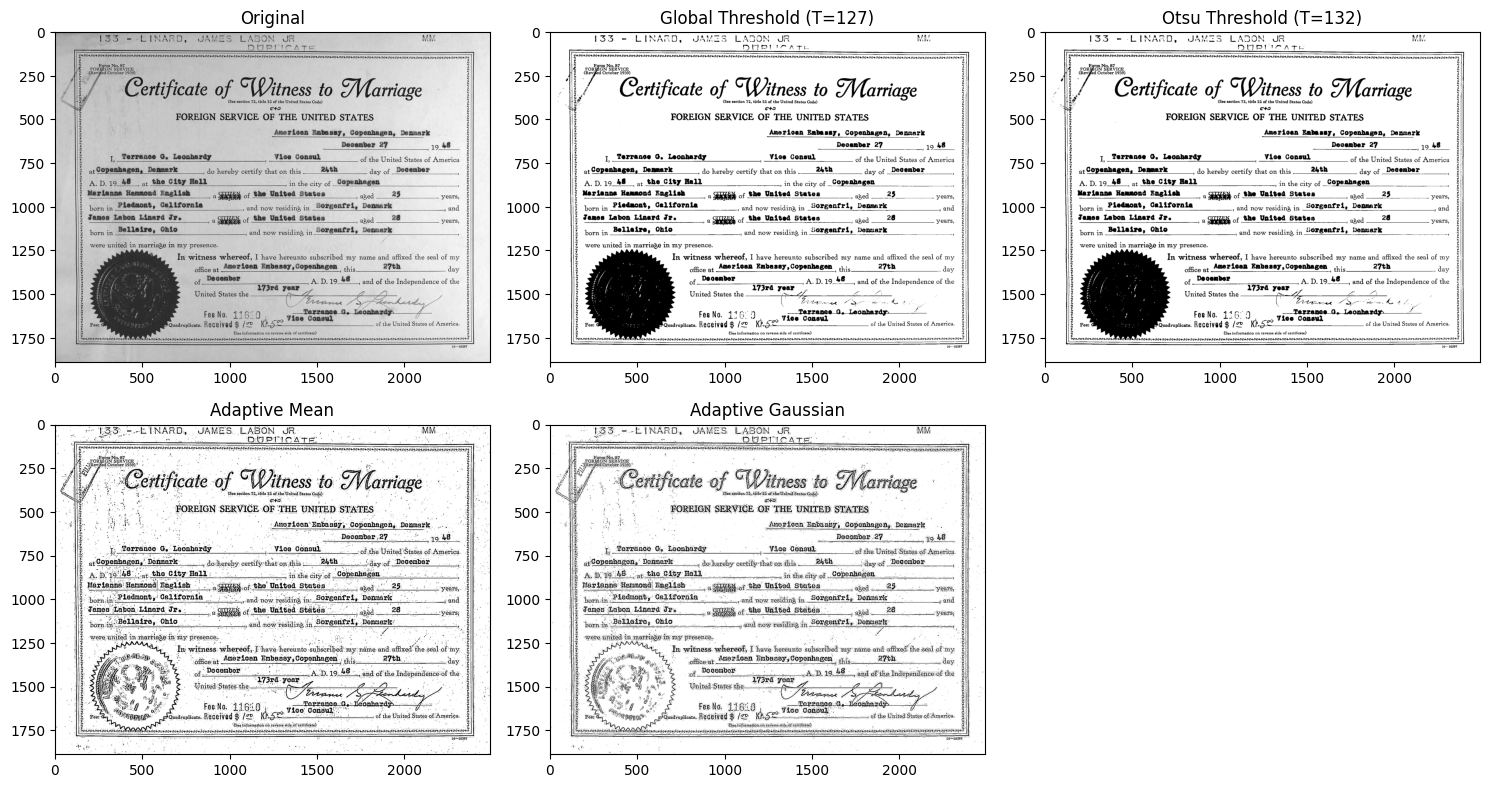

In [ ]:

# Load grayscale image
img = cv2.imread('document.jpg', cv2.IMREAD_GRAYSCALE)

# Check if image was loaded successfully
if img is None or img.size == 0:
    print("Error: Could not load image. Please check the file path and name.")
else:
    # 1. Simple global thresholding (manual T = 127)
    _, manual_thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

    # 2. Global thresholding using Otsu's method (T chosen automatically)
    otsu_val, otsu_thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    print('Otsu optimal threshold value:', otsu_val)

    # 3. Adaptive thresholding - Mean
    adaptive_mean = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                          cv2.THRESH_BINARY, blockSize=11, C=5)

    # 4. Adaptive thresholding - Gaussian
    adaptive_gauss = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                           cv2.THRESH_BINARY, blockSize=11, C=5)

    # Display results
    plt.figure(figsize=(15, 8))

    plt.subplot(2, 3, 1), plt.imshow(img, cmap='gray'),            plt.title('Original')
    plt.subplot(2, 3, 2), plt.imshow(manual_thresh, cmap='gray'),  plt.title('Global Threshold (T=127)')
    plt.subplot(2, 3, 3), plt.imshow(otsu_thresh, cmap='gray'),    plt.title(f'Otsu Threshold (T={otsu_val:.0f})')
    plt.subplot(2, 3, 4), plt.imshow(adaptive_mean, cmap='gray'),  plt.title('Adaptive Mean')
    plt.subplot(2, 3, 5), plt.imshow(adaptive_gauss, cmap='gray'), plt.title('Adaptive Gaussian')

    plt.tight_layout()
    plt.show()